In [15]:
import numpy as np
from math import comb
import matplotlib.pyplot as plt

In [16]:
def backward_diff(f, x, n, h=1e-3):
    """Approximate the n-th derivative of f at x using backward finite differences.

    f^(n)(x) ≈ (1/h^n) * sum_{k=0}^{n} (-1)^k * C(n,k) * f(x - k*h)
    """
    return sum((-1)**k * comb(n, k) * f(x - k * h) for k in range(n + 1)) / h**n


def backward_diff_array(y, h, n):
    """Approximate the n-th derivative from uniformly sampled data y with spacing h.

    Returns an array of length len(y) - n (valid region only).
    """
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    # convolve without reversing: numpy's convolution already handles the
    # summation order so that coeffs[k] multiplies y[i+n-k], matching
    # the backward difference formula at x[i+n].
    result = np.convolve(y, coeffs, mode='valid') / h**n
    return result

In [17]:
# Test: f(x) = sin(x), derivatives cycle through cos, -sin, -cos, sin, ...
x0 = 1.0
for n in range(1, 6):
    approx = backward_diff(np.sin, x0, n)
    # exact n-th derivative of sin(x) = sin(x + n*pi/2)
    exact = np.sin(x0 + n * np.pi / 2)
    print(f"n={n}  approx={approx:+.8f}  exact={exact:+.8f}  err={abs(approx - exact):.2e}")

n=1  approx=+0.54072295  exact=+0.54030231  err=4.21e-04
n=2  approx=-0.84093019  exact=-0.84147098  err=5.41e-04
n=3  approx=-0.54156368  exact=-0.54030231  err=1.26e-03
n=4  approx=+0.84010576  exact=+0.84147098  err=1.37e-03
n=5  approx=-1.33226763  exact=+0.54030231  err=1.87e+00


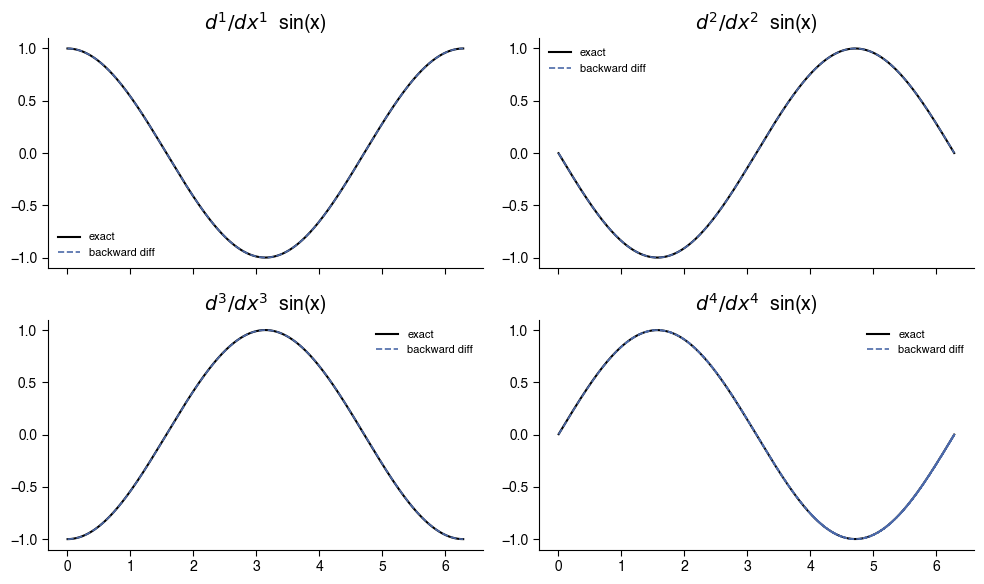

In [18]:
# Test backward_diff_array on sampled data
h = 1e-3
x = np.arange(0, 2 * np.pi, h)
y = np.sin(x)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, ax in enumerate(axes.flat):
    n = i + 1
    dy = backward_diff_array(y, h, n)
    x_valid = x[n:]  # valid region
    exact = np.sin(x_valid + n * np.pi / 2)
    ax.plot(x_valid, exact, 'k-', lw=1.5, label='exact')
    ax.plot(x_valid, dy, '--', lw=1.2, label='backward diff')
    ax.set_title(f'$d^{n}/dx^{n}$  sin(x)')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [19]:
from tools import load

sensor_data, sequence, times_sec, sequence_sec = load('1_600_20', reduced=True)
h = np.median(np.diff(times_sec))  # sampling interval in seconds

sensor_names = ["TGS2610", "TGS2600", "TGS2603", "TGS2630",
                "TGS2612", "TGS2620", "TGS1820", "TGS2611"]

print(f"sensor_data shape: {sensor_data.shape}, h = {h:.4f} s")
print(f"Sensors: {sensor_names}")

sensor_data shape: (11691, 8), h = 1.0000 s
Sensors: ['TGS2610', 'TGS2600', 'TGS2603', 'TGS2630', 'TGS2612', 'TGS2620', 'TGS1820', 'TGS2611']


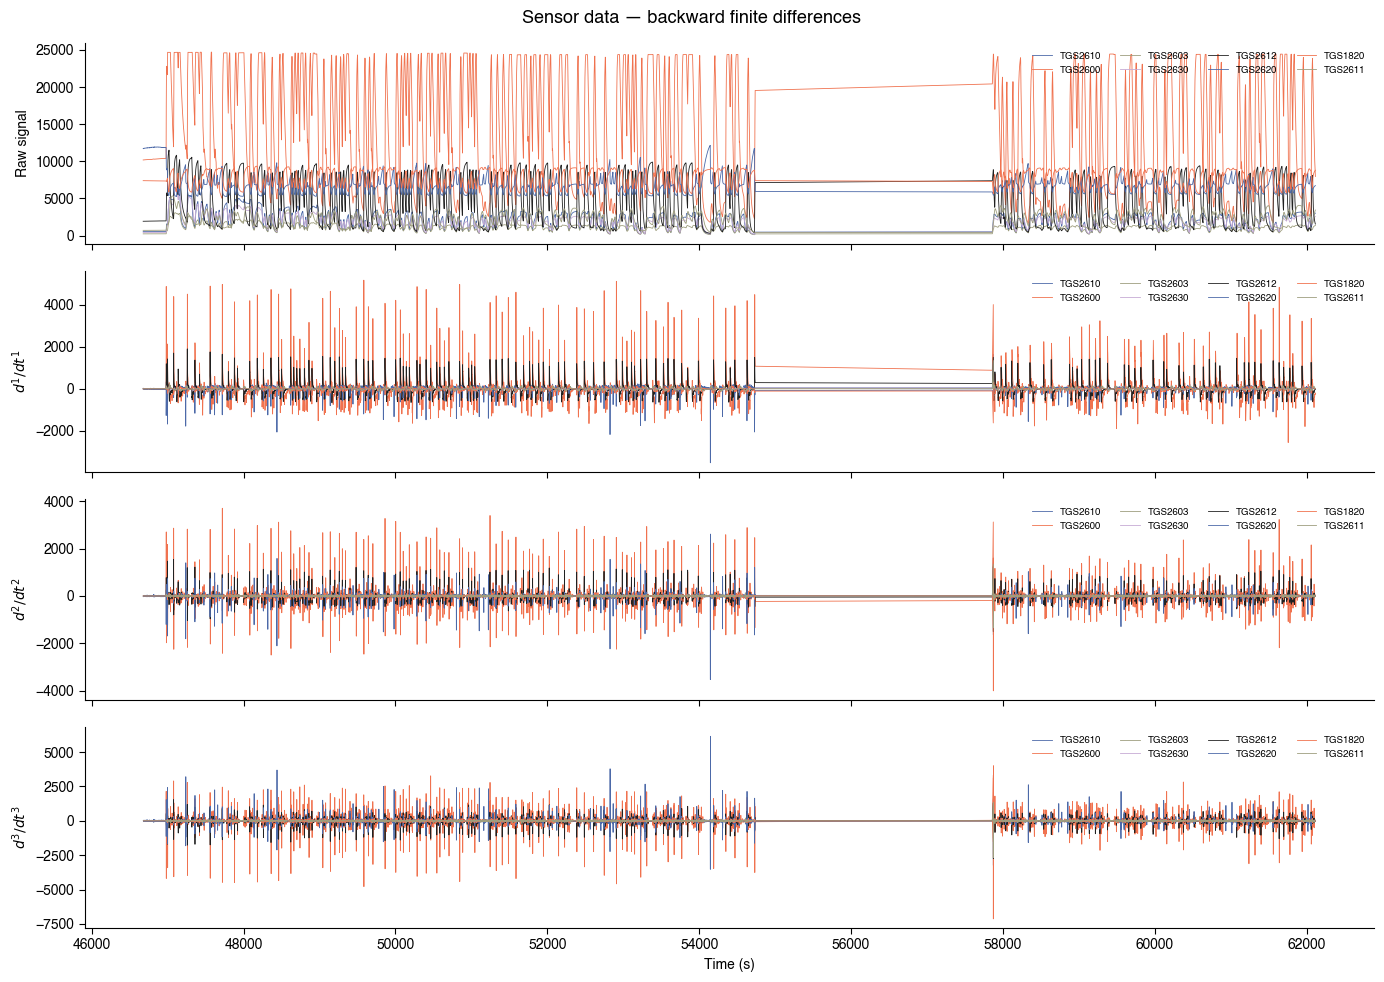

In [20]:
n_deriv = 3  # plot derivatives of order 0 (raw), 1, 2, 3

fig, axes = plt.subplots(n_deriv + 1, 1, figsize=(14, 2.5 * (n_deriv + 1)), sharex=True)

for n in range(n_deriv + 1):
    ax = axes[n]
    if n == 0:
        for s in range(sensor_data.shape[1]):
            ax.plot(times_sec, sensor_data[:, s], lw=0.6, label=sensor_names[s])
        ax.set_ylabel('Raw signal')
    else:
        for s in range(sensor_data.shape[1]):
            dy = backward_diff_array(sensor_data[:, s], h, n)
            t_valid = times_sec[n:]
            ax.plot(t_valid, dy, lw=0.6, label=sensor_names[s])
        ax.set_ylabel(f'$d^{{{n}}}/dt^{{{n}}}$')
    ax.legend(fontsize=7, ncol=4, loc='upper right')

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Sensor data — backward finite differences', fontsize=13)
fig.tight_layout()
plt.show()